1.What is the distribution of fuel types among the cars?

2.How does the selling price vary by year?

3.What is the average selling price for each fuel type?

4.How does the selling price relate to kilometers driven?

5.What is the distribution of car ownership (First Owner, Second Owner, etc.)?

6.What is the average price difference between manual and automatic transmissions?

7.Which year has the most cars listed for sale?

8.What is the most common seller type?

9.Are older cars priced significantly lower than newer ones?

10.What are the top 5 most expensive cars listed?

In [ ]:
import pandas as pd

# Load the dataset (Make sure the file is in the working directory)
df = pd.read_csv('/content/CAR_DETAILS.csv')

# Display the first few rows
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


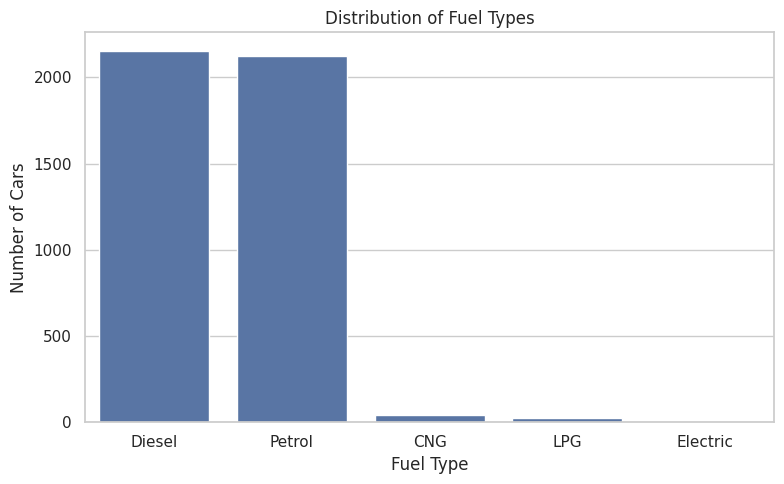

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='fuel', order=df['fuel'].value_counts().index)
plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()


Conclusion: Petrol cars dominate the listings, followed by diesel, with very few CNG and LPG vehicles.



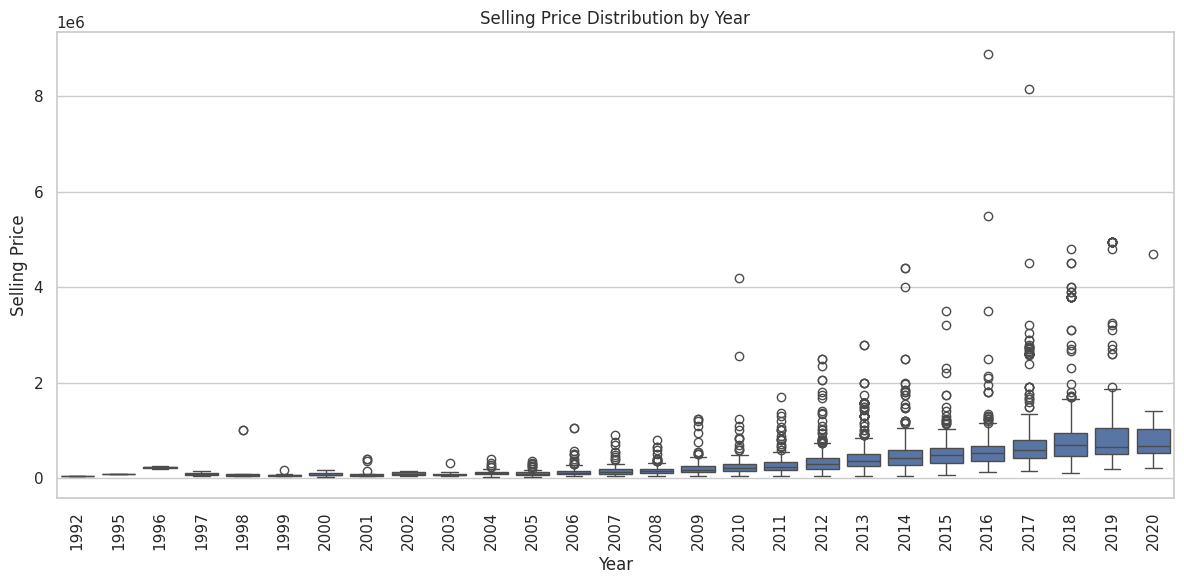

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year', y='selling_price')
plt.title('Selling Price Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Conclusion: Newer cars tend to have higher prices, with older cars showing more variability and lower prices.


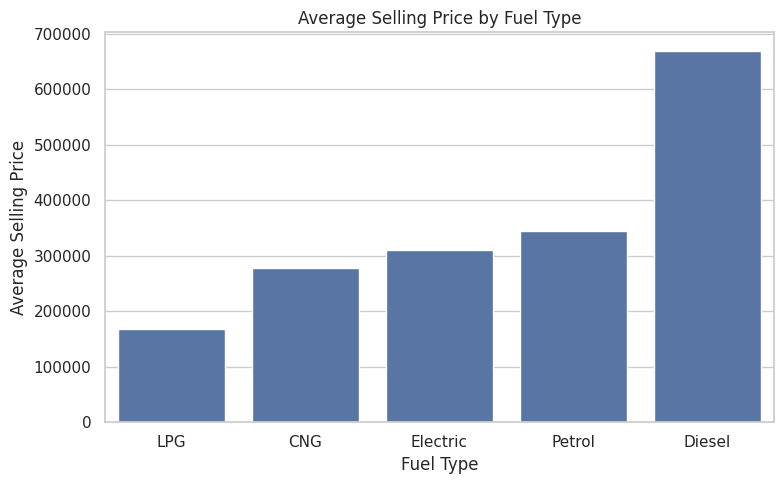

In [ ]:
plt.figure(figsize=(8, 5))
avg_price_by_fuel = df.groupby('fuel')['selling_price'].mean().sort_values()
sns.barplot(x=avg_price_by_fuel.index, y=avg_price_by_fuel.values)
plt.title('Average Selling Price by Fuel Type')
plt.ylabel('Average Selling Price')
plt.xlabel('Fuel Type')
plt.tight_layout()
plt.show()


Conclusion: Diesel cars have the highest average price, while LPG and Petrol tend to be more budget-friendly.

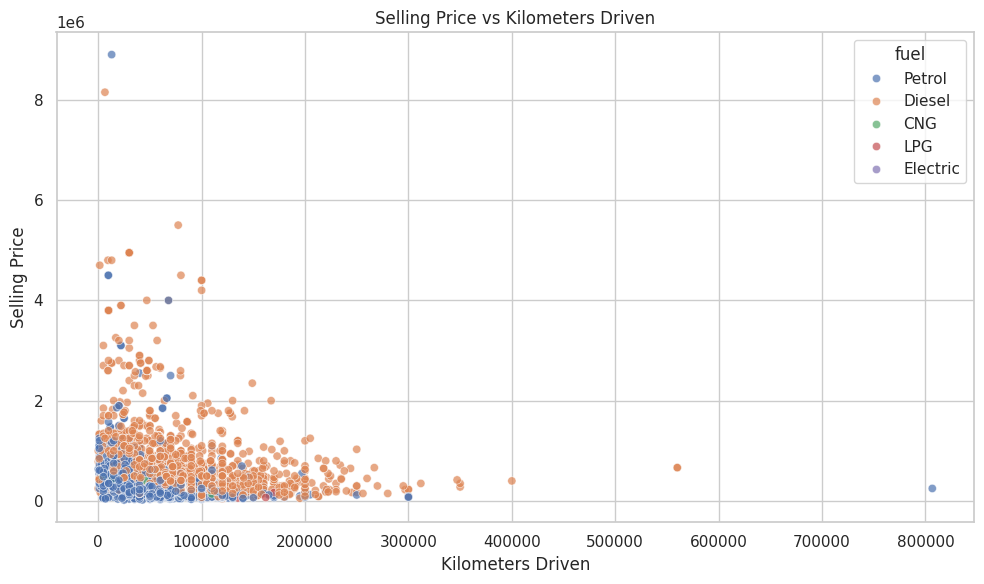

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='km_driven', y='selling_price', hue='fuel', alpha=0.7)
plt.title('Selling Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()


Conclusion: Generally, cars with lower mileage fetch higher prices, although outliers exist.



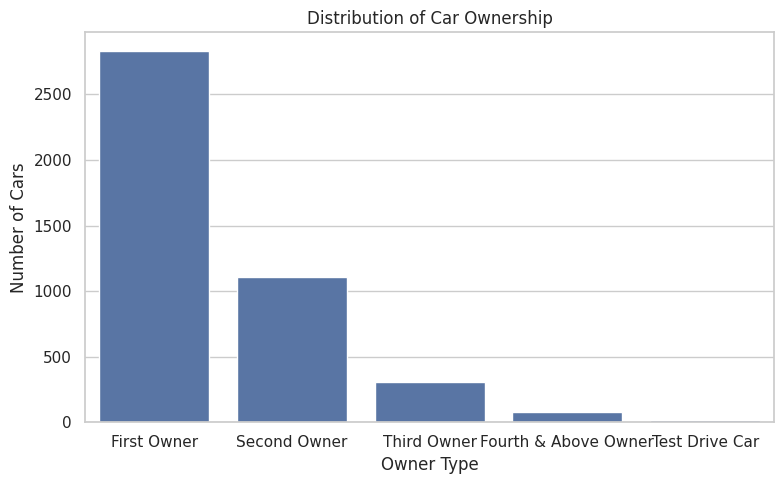

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='owner', order=df['owner'].value_counts().index)
plt.title('Distribution of Car Ownership')
plt.xlabel('Owner Type')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()


Conclusion: First-owner cars are the most common, which may indicate better value perception or trust.



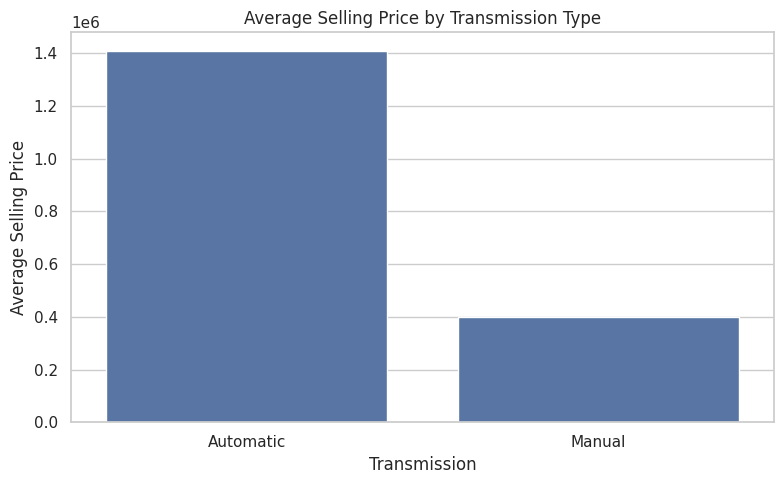

In [ ]:
plt.figure(figsize=(8, 5))
avg_price_by_trans = df.groupby('transmission')['selling_price'].mean()
sns.barplot(x=avg_price_by_trans.index, y=avg_price_by_trans.values)
plt.title('Average Selling Price by Transmission Type')
plt.ylabel('Average Selling Price')
plt.xlabel('Transmission')
plt.tight_layout()
plt.show()


Conclusion: Automatic cars are priced higher on average than manual ones, possibly due to convenience or newer models.



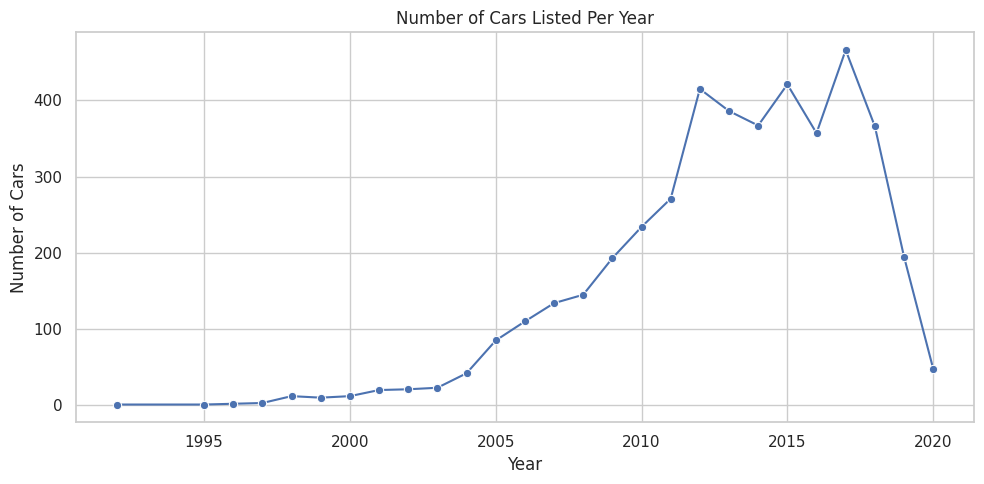

In [ ]:
plt.figure(figsize=(10, 5))
cars_per_year = df['year'].value_counts().sort_index()
sns.lineplot(x=cars_per_year.index, y=cars_per_year.values, marker='o')
plt.title('Number of Cars Listed Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()


Conclusion: There's an increasing trend in the number of listings for newer cars, peaking around 2017–2020.

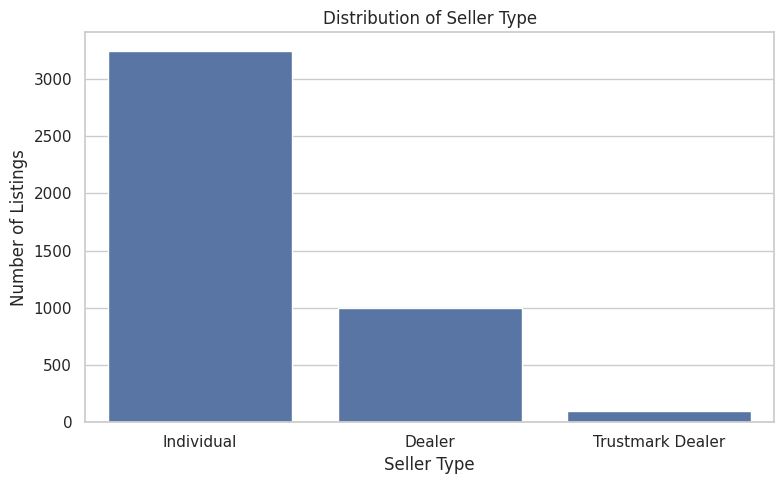

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='seller_type', order=df['seller_type'].value_counts().index)
plt.title('Distribution of Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()


Conclusion: Individuals make up the majority of sellers, followed by dealers and trustmark dealers.

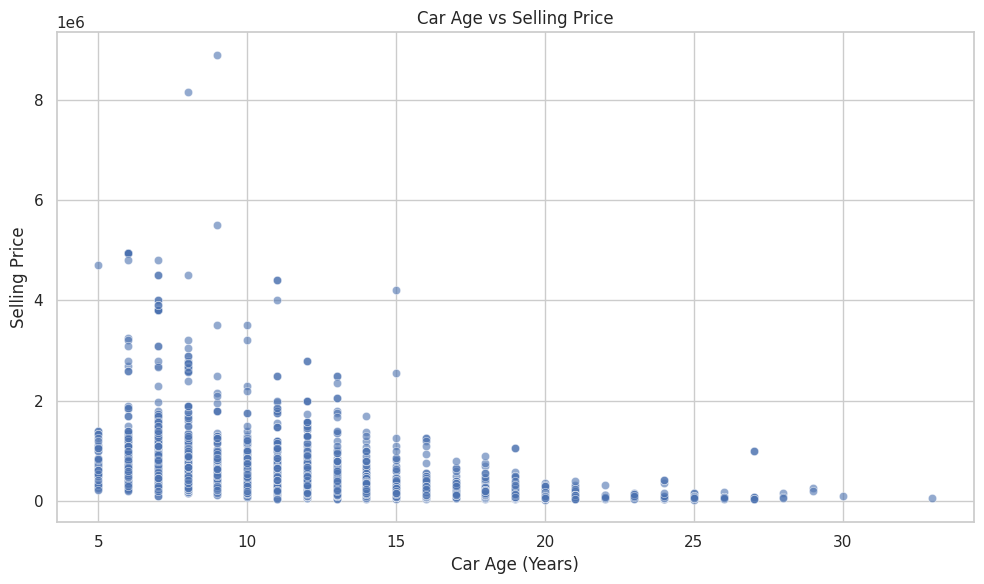

In [ ]:
df['car_age'] = 2025 - df['year']
plt.figure(figsize=(10, 6))
sns.scatterplot(x='car_age', y='selling_price', data=df, alpha=0.6)
plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()


Conclusion: Older cars generally have lower selling prices, but some still maintain value depending on condition and model.

<ipython-input-22-379a033e703f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='selling_price', y='name', data=top5, palette='viridis')


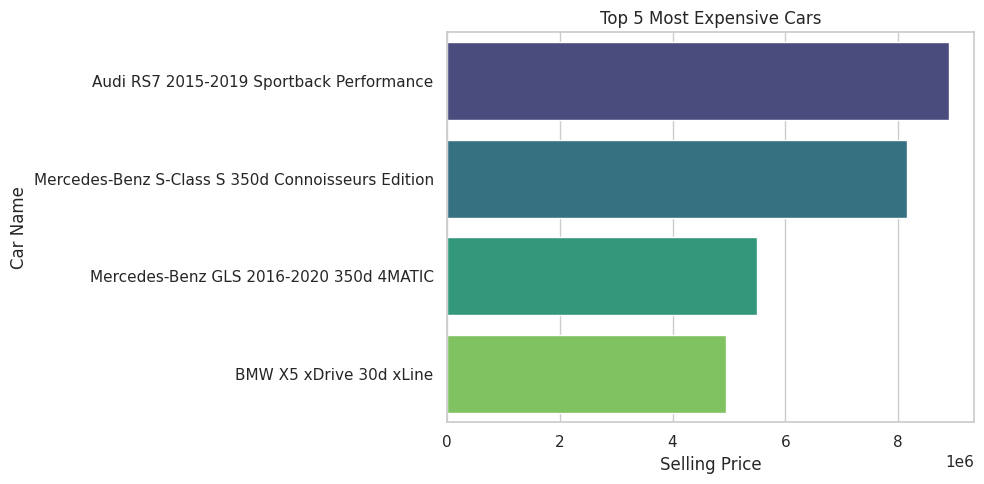

In [ ]:
top5 = df.nlargest(5, 'selling_price')[['name', 'selling_price']]
plt.figure(figsize=(10, 5))
sns.barplot(x='selling_price', y='name', data=top5, palette='viridis')
plt.title('Top 5 Most Expensive Cars')
plt.xlabel('Selling Price')
plt.ylabel('Car Name')
plt.tight_layout()
plt.show()


Conclusion: The most expensive cars are typically luxury or premium models from well-known brands.



In [ ]:
What is the percentage distribution of cars based on the seller type?

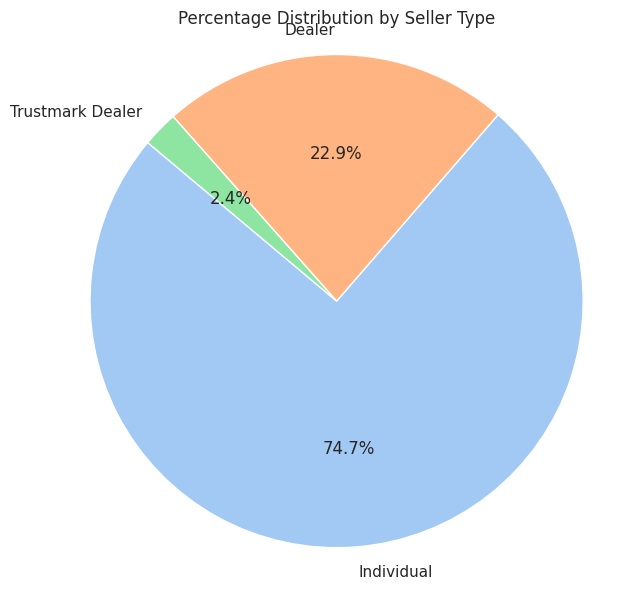

In [ ]:
import matplotlib.pyplot as plt

# Count of each seller type
seller_counts = df['seller_type'].value_counts()

# Pie chart
plt.figure(figsize=(7, 7))
plt.pie(seller_counts, labels=seller_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Percentage Distribution by Seller Type')
plt.axis('equal')  # Ensures the pie is drawn as a circle
plt.show()


🚗 Final Conclusion: Analysis of Car Listings Dataset
Fuel Type Trends

Petrol cars dominate the market, followed by Diesel.

CNG and LPG cars are much less common, indicating limited usage or availability.

Price Variation with Year

Newer cars are generally listed at higher prices.

Older cars show more variability in price, often influenced by mileage, brand, and condition.

Fuel vs Price

Diesel vehicles command higher average selling prices.

Petrol and LPG cars tend to be more budget-friendly.

Mileage Effect on Price

There's a negative correlation between kilometers driven and selling price.

Cars with lower mileage generally fetch higher prices, though there are exceptions (likely luxury cars or restored vehicles).

Ownership Patterns

The majority of cars are from first owners, making them more attractive to buyers.

Second and third owners are less common, potentially viewed as less reliable by buyers.

Transmission Insights

Automatic cars are priced higher than manual cars, likely due to being newer or more premium.

Manual cars remain common, possibly due to cost and availability.

Listings by Year

Listings have increased in recent years, especially for cars from 2015 to 2020.

This indicates a thriving second-hand market for relatively new vehicles.

Seller Type Distribution

Individuals are the main contributors to the listings, followed by dealers.

This suggests the platform is heavily used by private sellers, not just businesses.

Car Age and Price

As cars age, their value depreciates, with a sharp drop after 5–7 years.

However, some older models still hold significant value—likely luxury or rare models.

Top Expensive Cars

The most expensive cars are premium or luxury vehicles, often from well-known brands with high performance or prestige.



This pie chart shows the proportion of cars listed by individuals vs. dealers, revealing that individual sellers make up the majority of listings. It's a useful indicator of how the platform or marketplace is being used.